In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [18]:
x = np.sort(10 * np.random.rand(100))
noise_amp = 0.5
rng = np.random.default_rng(42) 
noise = rng.uniform(-noise_amp, noise_amp, size=x.shape)
y = np.cos(x) + noise                  


Created a version of cosine that uses randomness to enhance the strenght of the correlation

In [19]:
A = np.vstack([x, np.ones(len(x))]).T

# Solve using least squares

m, c = np.linalg.lstsq(A, y, rcond=None)[0]

print(f"Slope: {m}, Intercept: {c}")

Slope: -0.11653525267386114, Intercept: 0.5061471795749823


Prompted Chatgpt to see what it thought of ways to create catefories for over fit, good fit, and underfit 

Degree | MSE | R^2 | Fit Type
--------------------------------
     1 | 0.5201 | 0.1998 | underfit
     2 | 0.5130 | 0.2107 | underfit
     3 | 0.2173 | 0.6656 | good fit
     4 | 0.1837 | 0.7173 | good fit
     5 | 0.0764 | 0.8824 | good fit
     6 | 0.0730 | 0.8877 | good fit
     7 | 0.0706 | 0.8914 | good fit
     8 | 0.0680 | 0.8954 | good fit
     9 | 0.0680 | 0.8954 | overfit
    10 | 0.0677 | 0.8958 | overfit


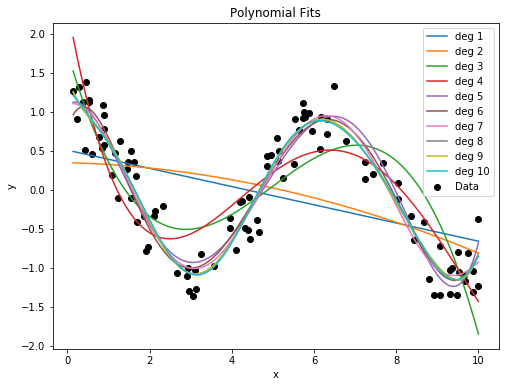

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='black', label='Data')

x_line = np.linspace(min(x), max(x), 200)

previous_mse = None

print("Degree | MSE | R^2 | Fit Type")
print("--------------------------------")

for degree in range(1, 11):

    coeffs = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coeffs)

    y_pred = polynomial(x)

   
    mse = np.mean((y - y_pred)**2)

    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r2 = 1 - ss_res/ss_total

   
    fit_type = "good fit"

    if r2 < 0.4:
        fit_type = "under fit"

    if previous_mse is not None:
        improvement = previous_mse - mse

        if improvement < 0.001:
            fit_type = "overfit"

    previous_mse = mse

    print(f"{degree:6} | {mse:6.4f} | {r2:6.4f} | {fit_type}")

    y_line = polynomial(x_line)
    plt.plot(x_line, y_line, label=f"deg {degree}")

plt.legend()
plt.title("Polynomial Fits")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Figured that using degree levels 1 through 10 would allow for maximum ability to observe how the degree of the polynomial affects the polyfit.